## Let's simulate OptimAc on the data collected by the survey

### Data import and formating into participant lists

In [38]:
import pandas as pan
from participant_real import Participant
from plotting import plotting_ba_bars,plot_violins 

dfs = [f0,f1]  = [pan.read_csv("../data/experimental2/filtered/f0.csv"), pan.read_csv("../data/experimental2/filtered/f1.csv")]

# f0 = f0[~f0["n"].isin([20,21,71,108])]
# f1 = f1[~f1["n"].isin([12,13,19,25,27,68,76,77,105,107,118])]

In [39]:
action_names = [["as_usual","monthly","weekly"],["monthly","notatall","weekly"]]
participants = [[],[]]

extract_data = lambda df :[
        (n, dict(zip(g["action_name"], g["motivation"])))
        for n, g in df.groupby("n")
    ]
# data is extracted from the dataframe as a list of (id, motivations list)
id_and_motivation_lists = [extract_data(f0), extract_data(f1)]

for scenario in range (2):
    for (id_number,motiv_dict) in id_and_motivation_lists[scenario]:
        
        participants[scenario].append(Participant(id_number,motiv_dict).to_dict())

part_dfs = [pan.DataFrame(participants[scenario]) for scenario in range(2)]



## Simulation

We use target distribution $d_i = 1/3$ with $pa_i = 10$

In [40]:
from Optimac import allocate_actions_to_participants_list

#d = [1/2,1/4,1/4]
d = [1/3,1/3,1/3]
D = 1/3
pa = 10

def simulate_scenario(scenario,participants) : 
    return allocate_actions_to_participants_list(participants,{ac : {"target": d[idx], "current":0,"minimum" :pa}for idx,ac in enumerate(action_names[scenario])})

## Results analysis

### Dropouts
Now let's compare dropouts with other methods, first we have to simulate those other methods on the participants. Note that the random method is treated aside due to its randomness.

In [41]:
import matplotlib.pyplot as plt 
import random as rd
from time import time
import numpy as np


feedback_map = {"Oui":1, "Oui, mais pas sûr":0.5,"Non":0}
methods = ["optimac","random","roundrobin","highestrank"]
det_methods = ["optimac","roundrobin","highestrank"]

def random_assignment(participant,scenario):
    selected = action_names[scenario][rd.randrange(3)]
    return (participant["id"],selected,participant["motivations"][selected])

def roundrobin_assignment(n,participant,scenario):
    selected = action_names[scenario][n%3]
    return (participant["id"],selected,participant["motivations"][selected])

def highestrank_assignment(participant,scenario):
    max_motiv = -float("inf")
    highest_ranked_action = ""
    motivs = list(participant["motivations"].items() )
    rd.shuffle(motivs)
    for (k,v) in motivs:
        if v > max_motiv:
            highest_ranked_action = k
            max_motiv = v
    return(participant["id"],highest_ranked_action,participant["motivations"][highest_ranked_action])


def compute_stats(scenario):
    #This function computes the number of participant per action before and after the dropouts simulation
    numbers_before = {m:[] for m in methods}
    stats_before={}
    deviations_before = {m:[] for m in methods}
    mean_dev_before = {}

    feedbacks = {}
    remaining_parts = {m:[] for m in methods}
    after_deviations= {m:[] for m in methods}
    stats_after = {m:[] for m in methods}
    mean_dev_after = {m:[] for m in methods}


    for _ in range(100):
        #computing the random assignments

        shuffled_parts = sorted(participants[scenario],key=lambda x: rd.random())

        assignments = {}
        # Simulation of the assignment procedures
        assignments["roundrobin"] = pan.DataFrame([roundrobin_assignment(idx,p,scenario) for idx,p in enumerate(shuffled_parts)],columns=["id","action","motivation"])
        assignments["highestrank"] = pan.DataFrame([highestrank_assignment(p,scenario) for p in shuffled_parts],columns=["id","action","motivation"])
        assignments["optimac"] = pan.DataFrame(simulate_scenario(scenario,shuffled_parts),columns=["id","action","motivation"])
        assignments["random"] = pan.DataFrame([random_assignment(p,scenario) for p in shuffled_parts],columns=["id","action","motivation"])


        #Simulation of dropouts
        random_dropouts = [rd.random() for _ in range(len(assignments["random"]))]

        for m in methods:
            cpt = assignments[m].groupby("action")["action"].count().reindex(action_names[scenario],fill_value=0)
            numbers_before[m].append(cpt.values)
            deviations_before[m].append(cpt.div(len(assignments[m])).sub(D).abs().values)
            feedbacks[m] = dfs[scenario].merge(assignments[m],left_on=["n", "action_name"], right_on=["id", "action"], how="inner")[["id","action","feedback"]]
            feedbacks[m]["feedback"] = feedbacks[m]["feedback"].map(feedback_map) 
       
            survivors_cpt = feedbacks[m][feedbacks[m]["feedback"]>random_dropouts].groupby("action")["action"].count().reindex(action_names[scenario],fill_value=0)

            remaining_parts[m].append(survivors_cpt.values)
            after_deviations[m].append(survivors_cpt.div(len(assignments[m])).sub(D).abs().values)
    
    for m in methods:
        array = np.array(numbers_before[m])
        stats_before[m] = [array.mean(axis =0),array.std(axis = 0)]
        array = np.array(deviations_before[m])
        mean_dev_before[m] = [array.mean(axis =0),array.std(axis = 0)]


        array = np.array(remaining_parts[m])
        stats_after[m] =[array.mean(axis = 0),array.std(axis=0)]
        array = np.array(after_deviations[m])
        mean_dev_after[m] = [array.mean(axis = 0),array.std(axis=0)]
    

    part_ratios = {m : np.array(remaining_parts[m])/np.array(numbers_before[m]) for m in methods}
    return stats_before,stats_after,mean_dev_before,mean_dev_after,after_deviations,part_ratios




Now let's analyze the results from these simulations.

In [42]:
methods = ["optimac","random","roundrobin","highestrank"]
method_colors = {
    "optimac": "#1f77b4",
    "highestrank": "#ff7f0e",
    "random": "#2ca02c",
    "roundrobin": "#d62728"
}
hatch_before = ""
hatch_after = "/"

scenario_names = ["Lawn mowing","Bird feeding"]

data=[(),()]

for scenario in range(2):
    data[scenario] = tuple( compute_stats(scenario))
    

/tmp/ipykernel_28206/206618610.py:86: RuntimeWarning: invalid value encountered in divide
  part_ratios = {m : np.array(remaining_parts[m])/np.array(numbers_before[m]) for m in methods}


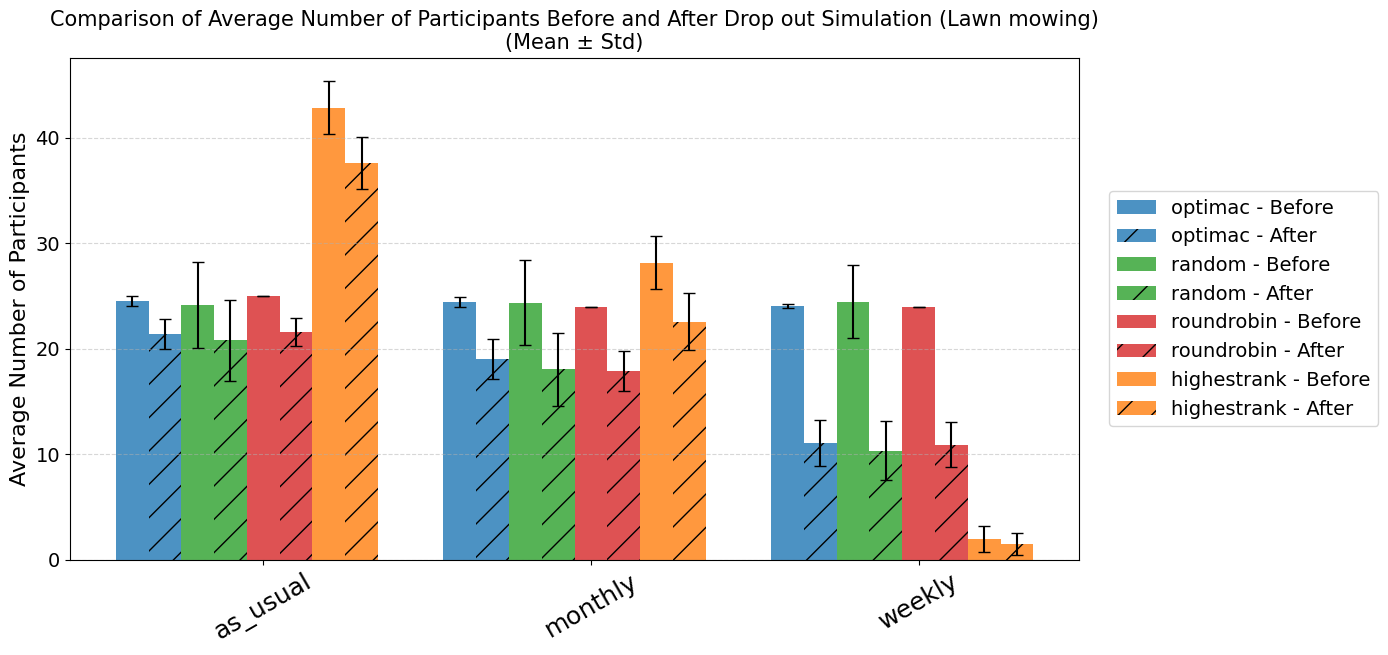

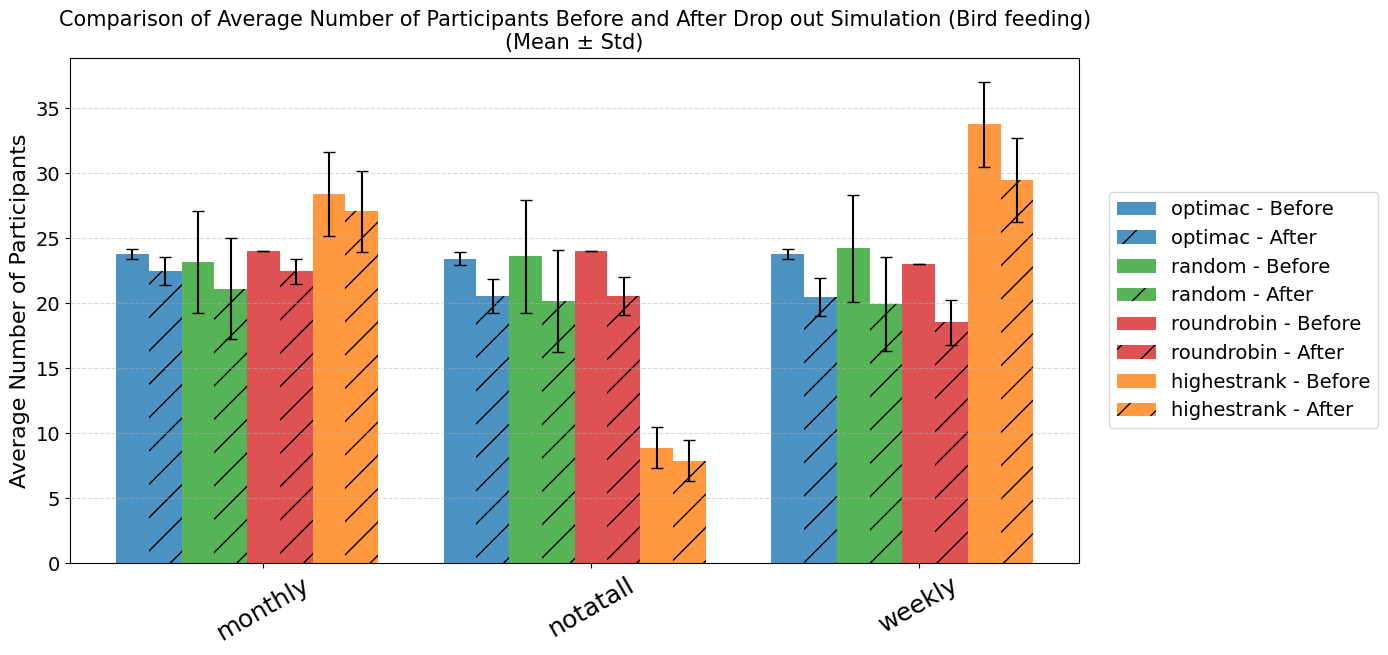

In [43]:
for scenario in range(2):
    [stats_before,stats_after,_,_,_,_] = data[scenario]
    plotting_ba_bars(scenario,stats_before, stats_after,f"Comparison of Average Number of Participants Before and After Drop out Simulation ({scenario_names[scenario]})\n(Mean ± Std)","Average Number of Participants")


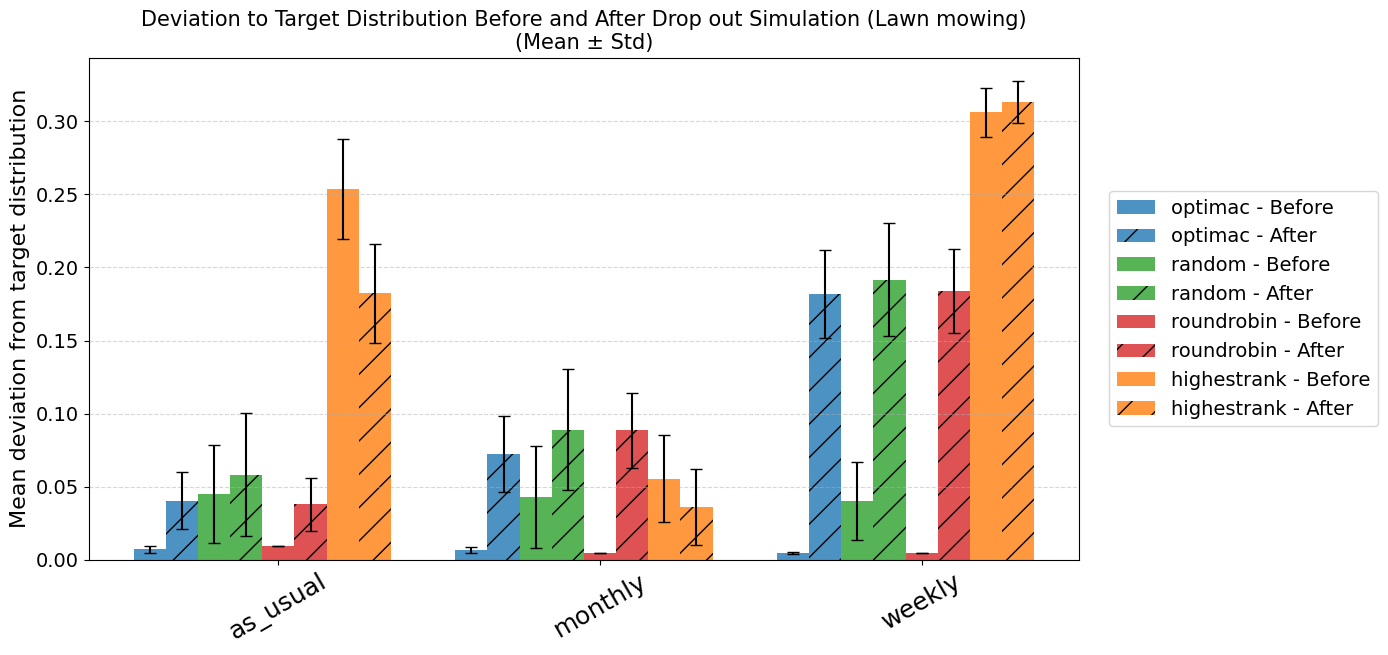

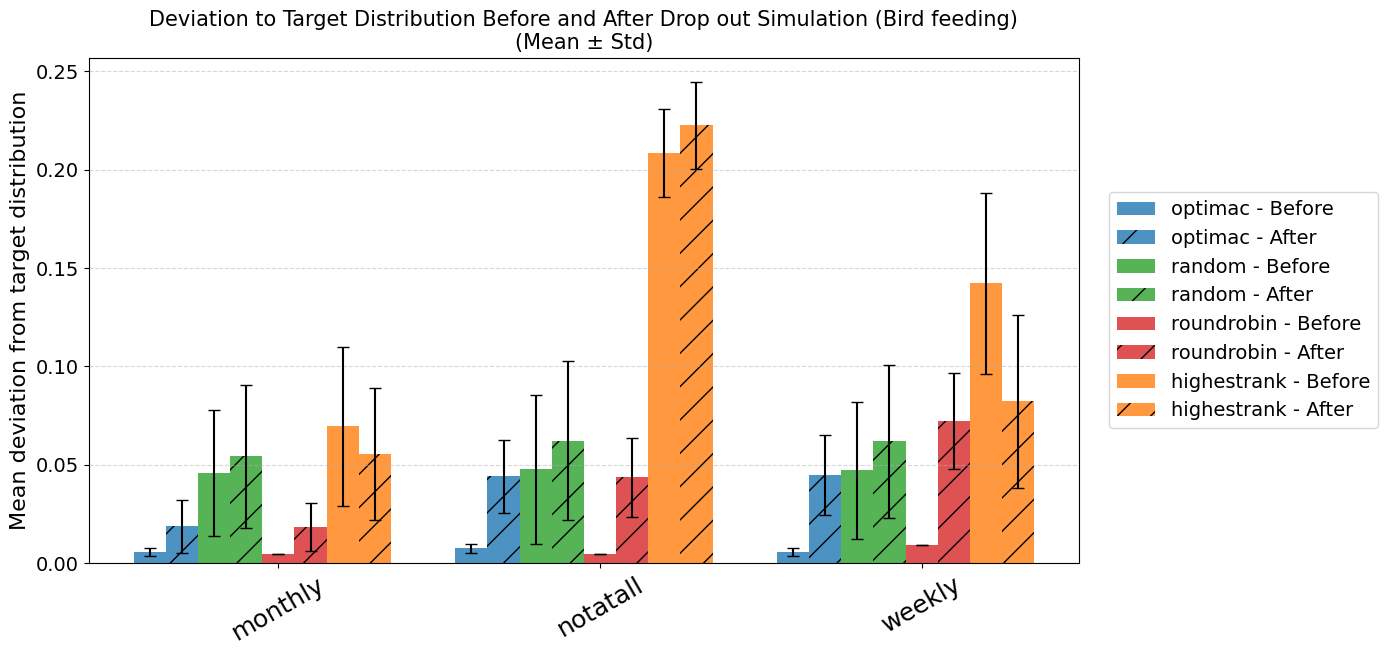

In [44]:
for scenario in range(2):
    [_,_,dev_before,dev_after,_,_] = data[scenario]
    plotting_ba_bars(scenario,dev_before,dev_after,f"Deviation to Target Distribution Before and After Drop out Simulation ({scenario_names[scenario]})\n(Mean ± Std)","Mean deviation from target distribution")


### Analysis of mean participation and mean deviation


/home/nov/Documents/Pro/M1/projet/OptimacForm/simulation/plotting.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, fontsize=18)


1.7282957288306993e-11 <class 'numpy.float64'>
0.0008392954933022406 <class 'numpy.float64'>
2.194503125843285e-34 <class 'numpy.float64'>
1.0177446319823142e-05 <class 'numpy.float64'>
2.728256583010879e-34 <class 'numpy.float64'>
2.108313372854352e-34 <class 'numpy.float64'>
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

optimac vs. random: Custom statistical test, P_val:5.185e-11
random vs. roundrobin: Custom statistical test, P_val:2.035e-05
roundrobin vs. highestrank: Custom statistical test, P_val:1.265e-33
optimac vs. roundrobin: Custom statistical test, P_val:8.393e-04
random vs. highestrank: Custom statistical test, P_val:1.265e-33
optimac vs. highestrank: Custom statistical test, P_val:1.265e-33

Significant differences (Holm-corrected Mann-Whitney U-tests):
 - optimac vs random: Significant (p = 5.184887186492098e-11)
 - optimac vs 

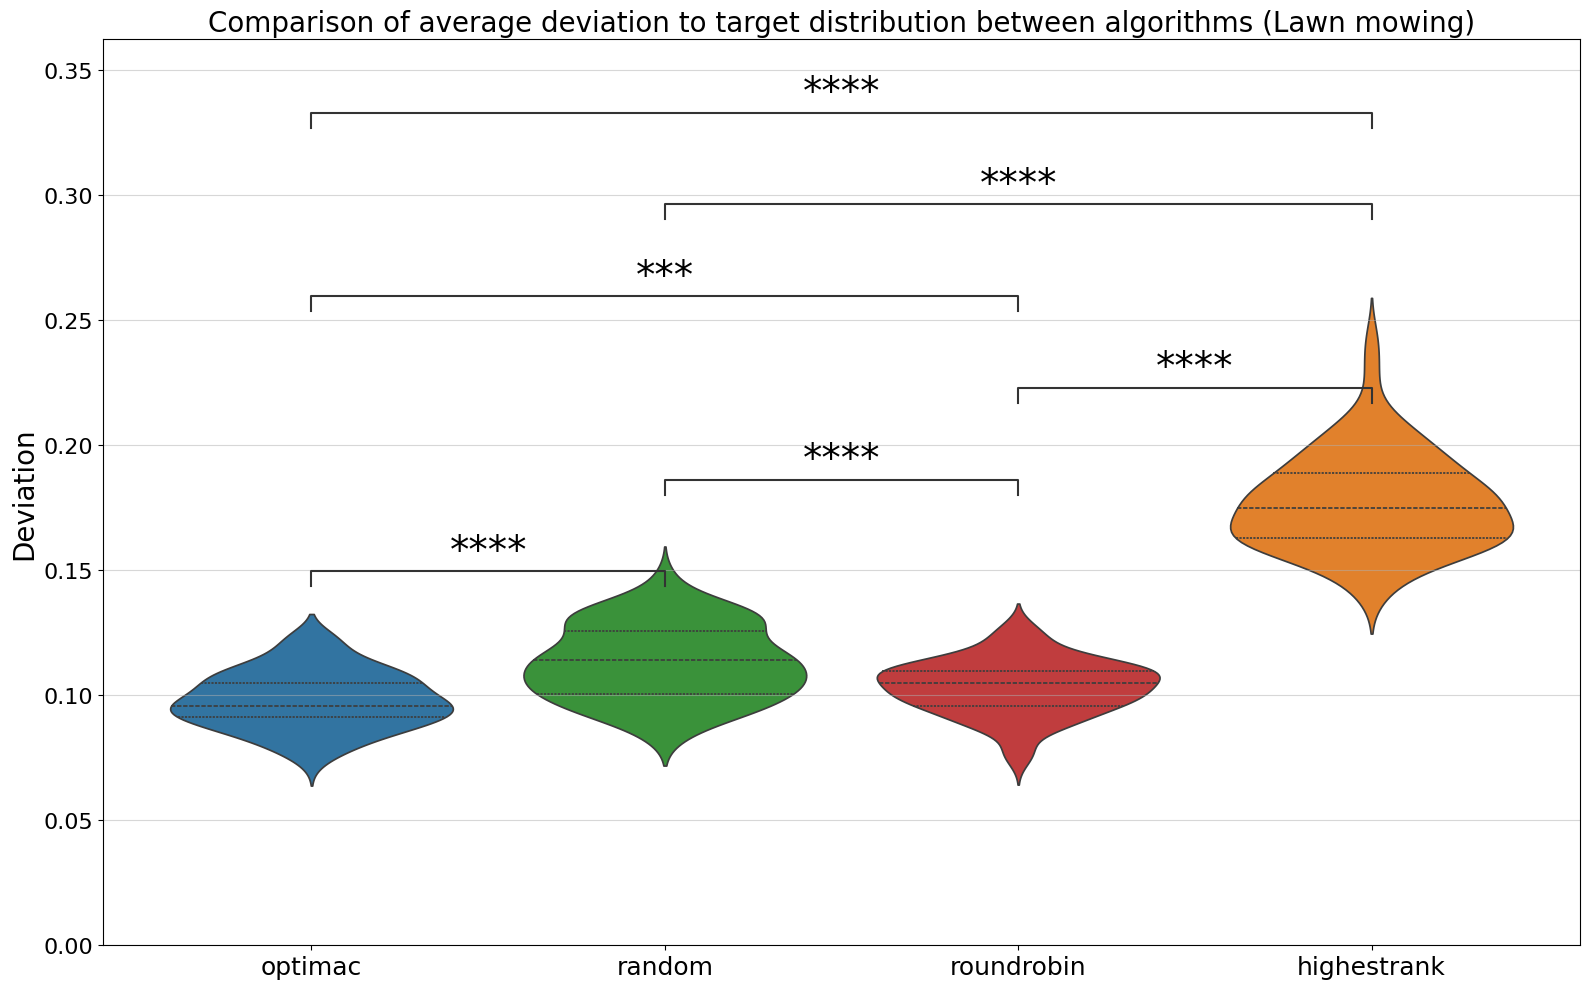

/home/nov/Documents/Pro/M1/projet/OptimacForm/simulation/plotting.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, fontsize=18)


6.226138624566228e-25 <class 'numpy.float64'>
1.2120381703983483e-08 <class 'numpy.float64'>
2.294985330394115e-34 <class 'numpy.float64'>
2.2994483223295244e-11 <class 'numpy.float64'>
1.193333946901505e-32 <class 'numpy.float64'>
2.363379429664999e-34 <class 'numpy.float64'>
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

optimac vs. random: Custom statistical test, P_val:1.868e-24
random vs. roundrobin: Custom statistical test, P_val:4.599e-11
roundrobin vs. highestrank: Custom statistical test, P_val:1.377e-33
optimac vs. roundrobin: Custom statistical test, P_val:1.212e-08
random vs. highestrank: Custom statistical test, P_val:4.773e-32
optimac vs. highestrank: Custom statistical test, P_val:1.377e-33

Significant differences (Holm-corrected Mann-Whitney U-tests):
 - optimac vs random: Significant (p = 1.8678415873698682e-24)
 - optimac vs

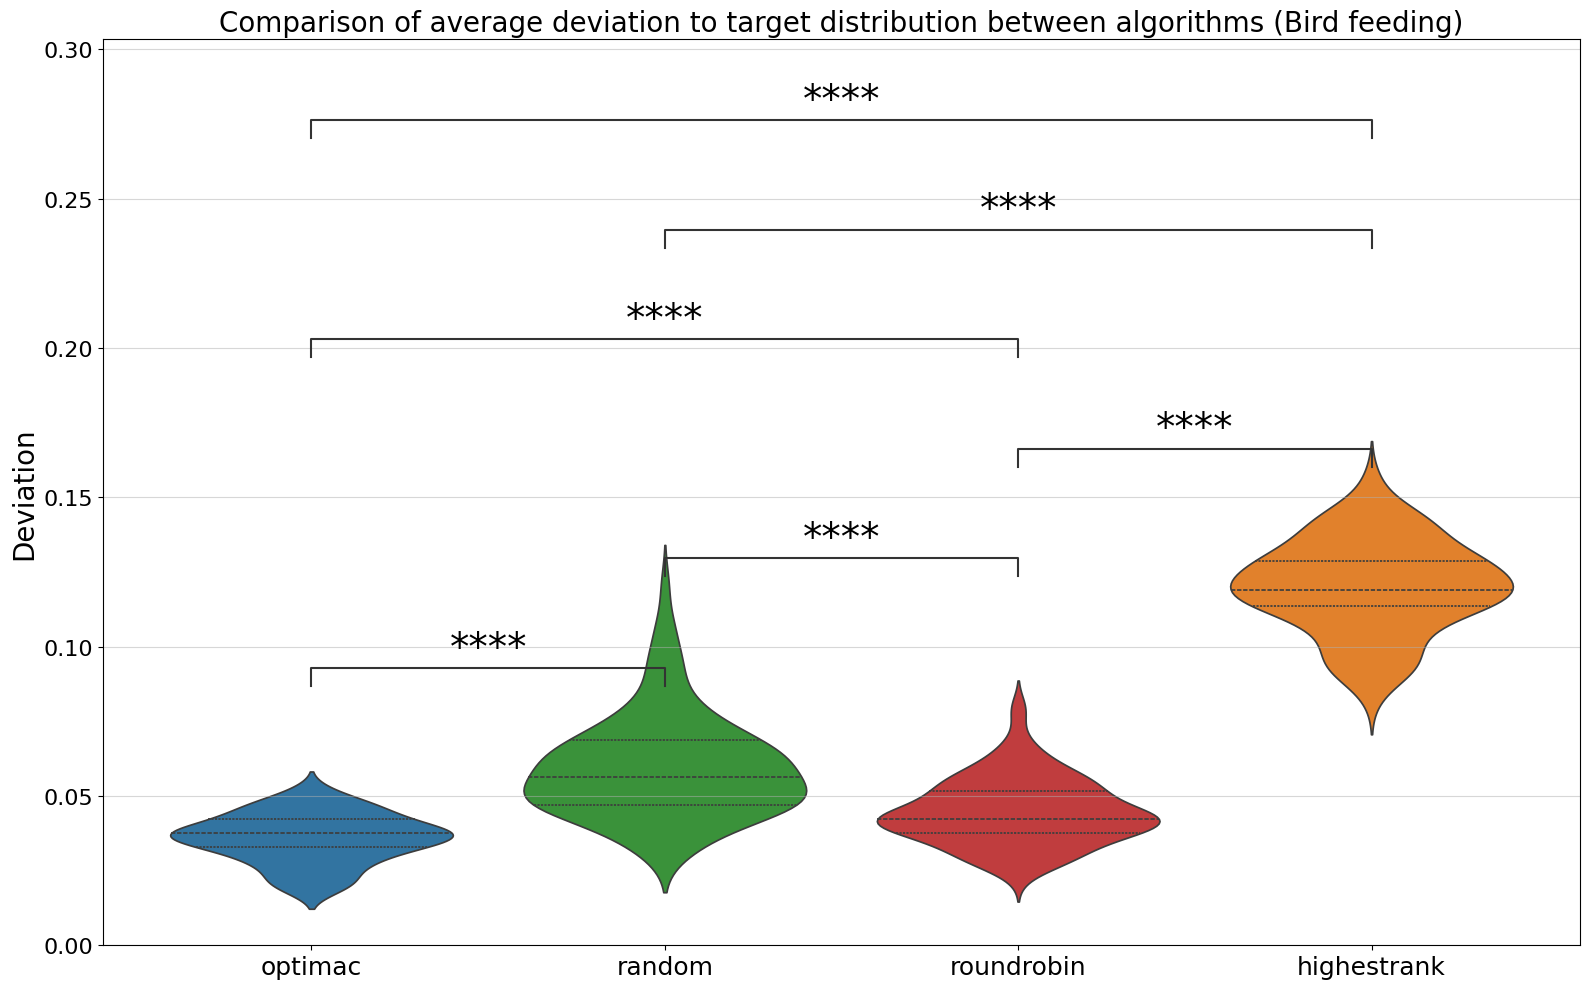

In [45]:
for scenario in range(2):
    [_,_,_,_,devs,_] = data[scenario]
    x = {m : np.array(devs[m]).mean(axis = 1) for m in methods}
    plot_violins(x, f"Comparison of average deviation to target distribution between algorithms ({scenario_names[scenario]})","Deviation",ylim=(0,0.3))

/home/nov/Documents/Pro/M1/projet/OptimacForm/simulation/plotting.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, fontsize=18)


6.863659661520208e-07 <class 'numpy.float64'>
0.00040351116376278546 <class 'numpy.float64'>
0 <class 'int'>
0.05325293721548032 <class 'numpy.float64'>
0 <class 'int'>
0 <class 'int'>
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

optimac vs. random: Custom statistical test, P_val:2.059e-06
random vs. roundrobin: Custom statistical test, P_val:5.325e-02
roundrobin vs. highestrank: Custom statistical test, P_val:0.000e+00
optimac vs. roundrobin: Custom statistical test, P_val:8.070e-04
random vs. highestrank: Custom statistical test, P_val:0.000e+00
optimac vs. highestrank: Custom statistical test, P_val:0.000e+00

Significant differences (Holm-corrected Mann-Whitney U-tests):
 - optimac vs random: Significant (p = 2.0590978984560626e-06)
 - optimac vs roundrobin: Significant (p = 0.0008070223275255709)
 - optimac vs highestrank: Significant (

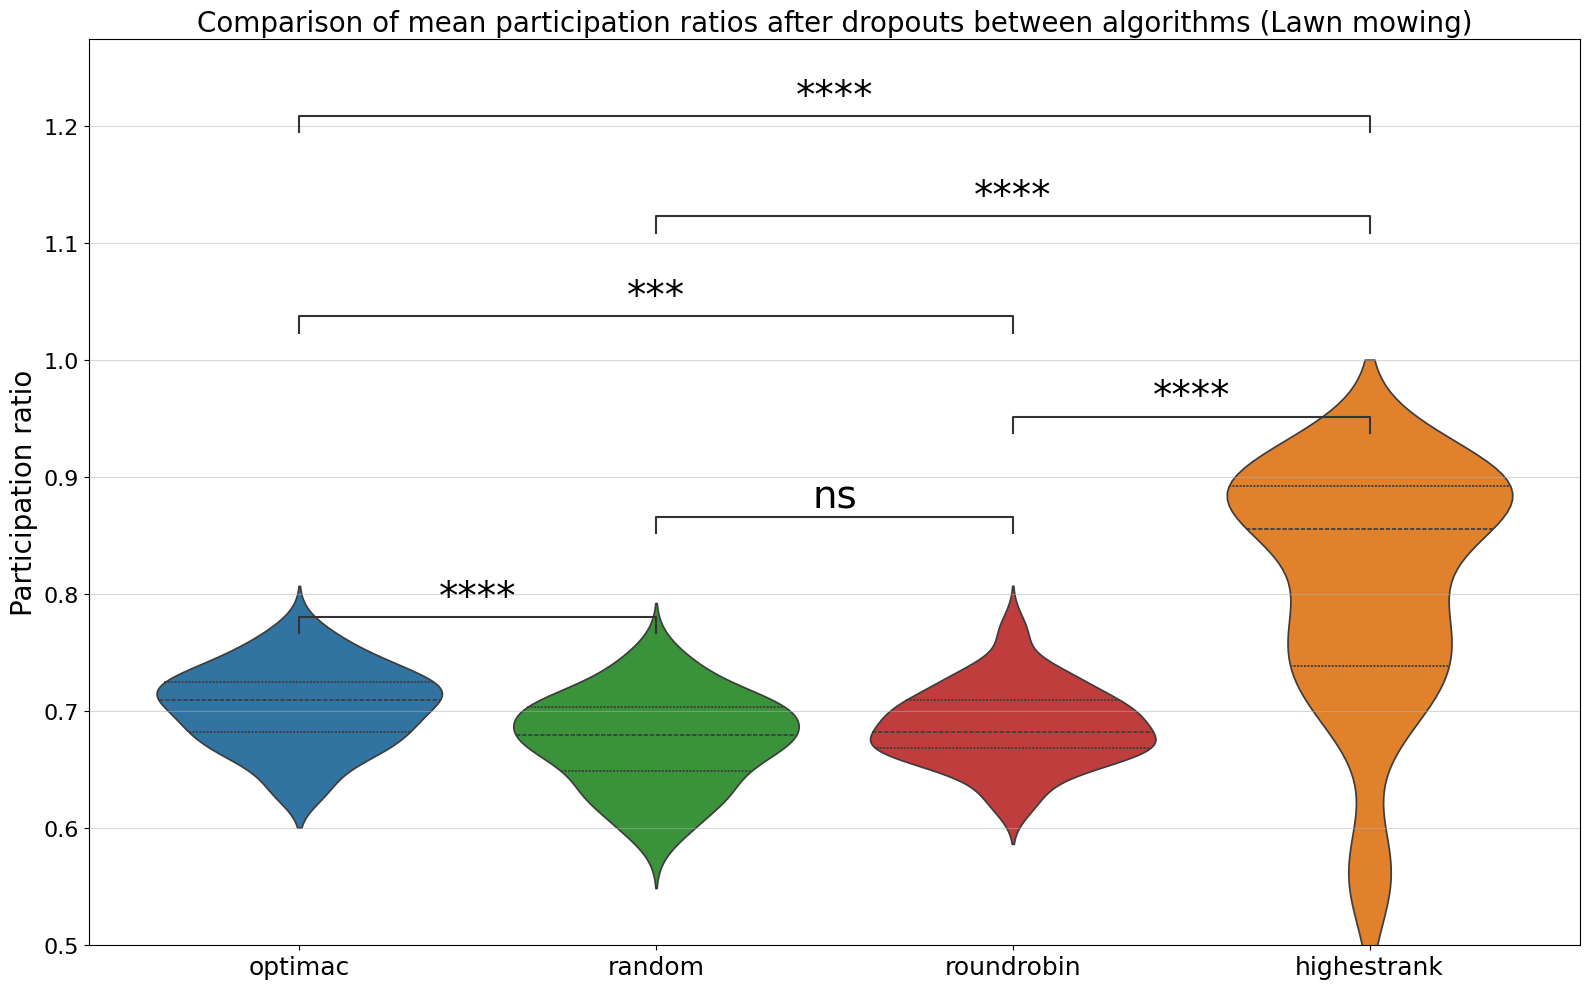

/home/nov/Documents/Pro/M1/projet/OptimacForm/simulation/plotting.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, fontsize=18)


1.959287718915728e-10 <class 'numpy.float64'>
5.53515035368808e-10 <class 'numpy.float64'>
0.0010724238387320192 <class 'numpy.float64'>
0.31817513624804983 <class 'numpy.float64'>
6.066178888906242e-18 <class 'numpy.float64'>
1.308894836270789e-16 <class 'numpy.float64'>
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

optimac vs. random: Custom statistical test, P_val:7.837e-10
random vs. roundrobin: Custom statistical test, P_val:3.182e-01
roundrobin vs. highestrank: Custom statistical test, P_val:6.544e-16
optimac vs. roundrobin: Custom statistical test, P_val:1.661e-09
random vs. highestrank: Custom statistical test, P_val:3.640e-17
optimac vs. highestrank: Custom statistical test, P_val:2.145e-03

Significant differences (Holm-corrected Mann-Whitney U-tests):
 - optimac vs random: Significant (p = 7.837150875662912e-10)
 - optimac vs round

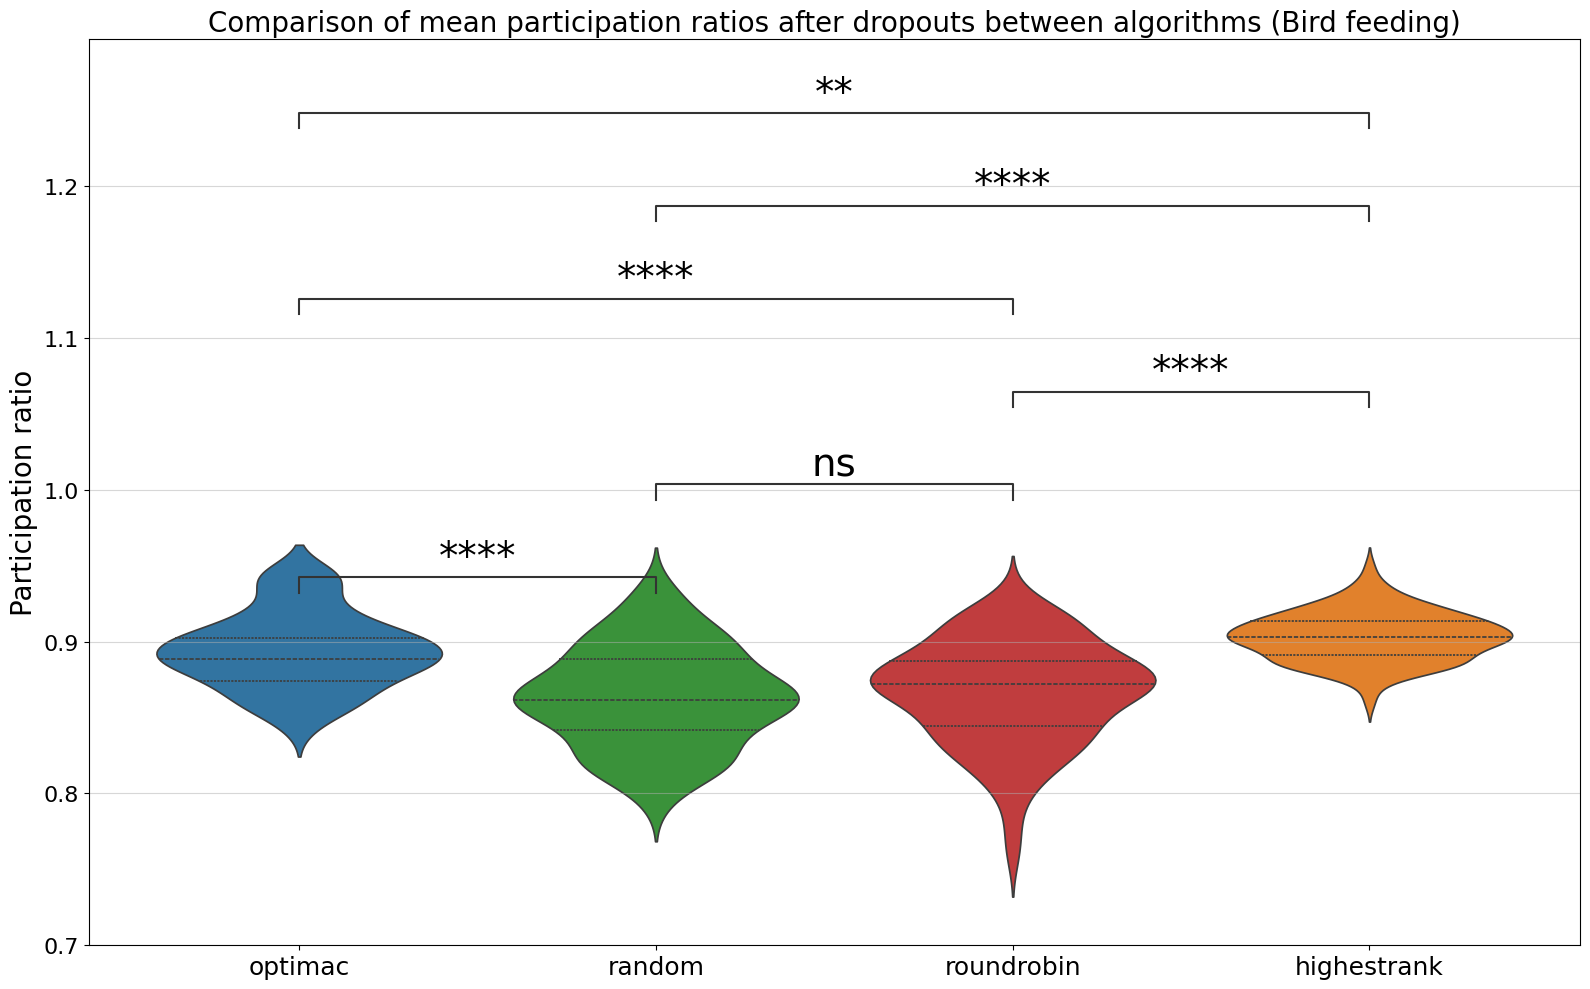

In [48]:
ylims = [(0.5,1.2),(0.7,1.2)]
for scenario in range(2):
    [_,_,_,_,_,part_ratios] = data[scenario]
    ratios = {m : part_ratios[m].mean(axis = 1) for m in methods}
    plot_violins(ratios, f"Comparison of mean participation ratios after dropouts between algorithms ({scenario_names[scenario]})","Participation ratio",ylim = ylims[scenario])